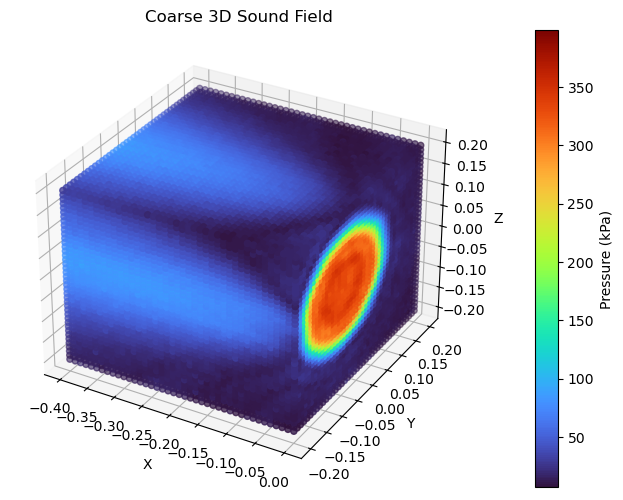

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

sens = 2.149e-007 

def plot3D(file, title):
    XYZ = pd.read_csv(file)
    P = XYZ.Amp / 2e6 / sens

    fig = plt.figure(figsize=(14, 5))
    ax = fig.add_subplot(1, 2, 1, projection='3d')

    sc = ax.scatter(
        XYZ.X, XYZ.Y, XYZ.Z,
        c=P,
        cmap='turbo'
    )

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.set_title(title)

    cbar = fig.colorbar(sc, ax=ax, pad=0.1)
    cbar.set_label('Pressure (kPa)')

    plt.tight_layout()
    plt.show()

plot3D("XYZ.csv", "Coarse 3D Sound Field")

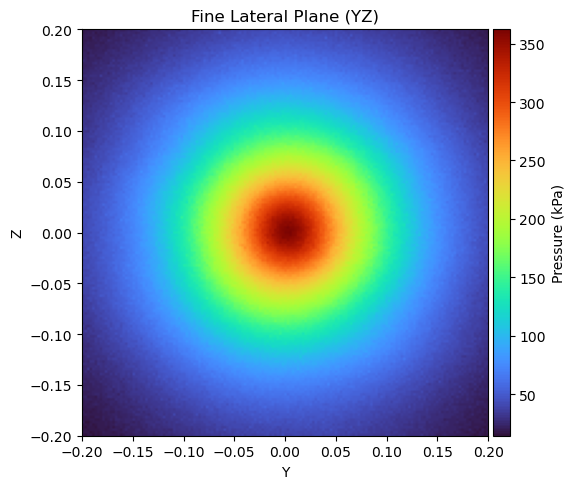

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

sens = 2.149e-7

planes = {
    "XY": ("X", "Y", "Z"),
    "XZ": ("X", "Z", "Y"),
    "YZ": ("Y", "Z", "X"),
}

def plot2D(file, plane, title):
    cx, ix, slice_axis = planes[plane]
    d = pd.read_csv(file)

    z = d[slice_axis].round(6)
    d = d[np.isclose(z, z.mode()[0])]
    d["P"] = d["Amp"] / (2e6 * sens)

    p = d.pivot_table(index=ix, columns=cx, values="P").sort_index().sort_index(axis=1)

    x = p.columns.values
    y = p.index.values

    xr = x.max() - x.min()
    yr = y.max() - y.min() or 1
    w = np.clip(5 * xr / yr, 6, 14)
    h = np.clip(max(5, w * 0.3), 4, 8)

    fig, ax = plt.subplots(figsize=(w, h))

    im = ax.imshow(
        p.values,
        origin="lower",
        aspect="equal",
        cmap="turbo",
        extent=[x.min(), x.max(), y.min(), y.max()]
    )

    ax.set(xlabel=cx, ylabel=ix, title=title)

    cbar = fig.colorbar(im, cax=make_axes_locatable(ax).append_axes("right", "4%", pad=0.05))
    cbar.set_label("Pressure (kPa)")

    plt.tight_layout()
    plt.show()

plot2D("YZ.csv", "YZ", "Fine Lateral Plane (YZ)")

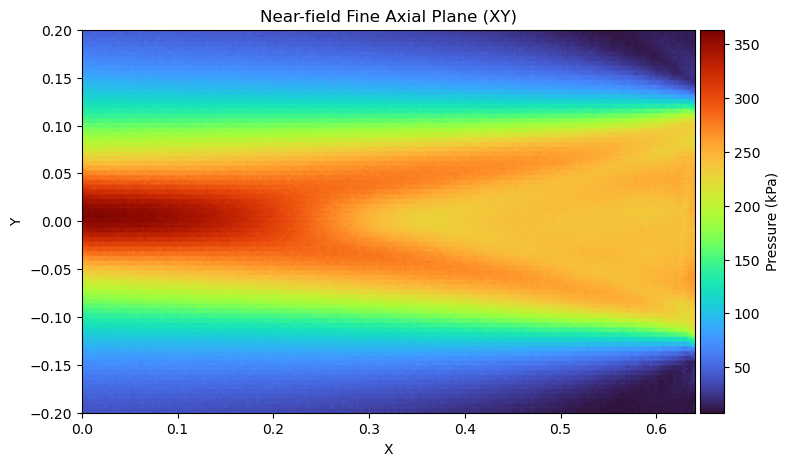

In [26]:
plot2D("XY.csv", "XY", "Near-field Fine Axial Plane (XY)")

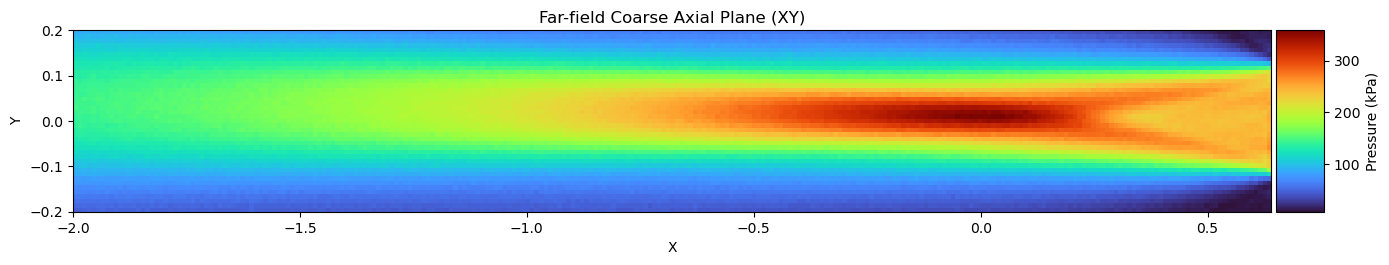

In [28]:
plot2D("XY Coarse.csv", "XY", "Far-field Coarse Axial Plane (XY)")

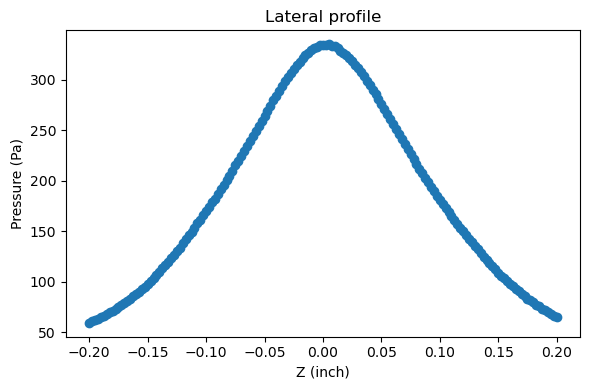

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sens = 2.149e-7

def plot1D(csv, axis, title):
    data = pd.read_csv(csv)

    data["P"] = data["Amp"] / 1e6 / sens

    df = data[[axis, "P"]].groupby(axis, as_index=False).mean()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df[axis], df["P"])
    ax.set_xlabel(f"{axis} (inch)")
    ax.set_ylabel("Pressure (kPa)")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()
plot1D("YZ.csv", "Z", "Lateral profile")

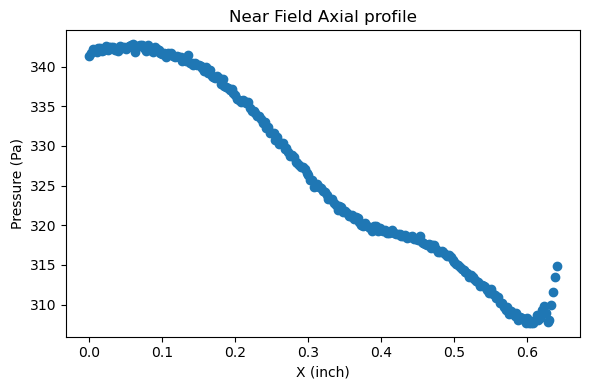

In [23]:
plot1D("XY.csv", "X", "Near Field Axial profile")

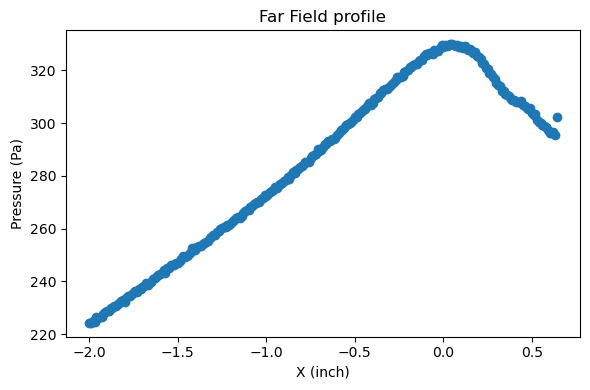

In [24]:

plot1D("XY Coarse.csv", "X", "Far Field profile")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv('Focus.csv')
p = data.iloc[:, 0].values / 1e6 / sens
dt = 0.016  # ns per sample
x = np.arange(len(p)) * dt  # time axis in ns
plt.plot(x, p)
plt.xlabel('Time (us)')
plt.ylabel('Pressure (kPa)')
plt.title('Representitive Signal')
plt.grid(True)
plt.show()